# Experiment 7: Model Optimization

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Model:** Experiment 2 MNIST baseline ANN

**Aim:** Optimize a previously trained deep learning model for deployment using quantization and
pruning, and measure the resulting trade-off between model size, inference latency, and accuracy.

**Note on tooling:** the `tensorflow-model-optimization` package (the standard library for this
step) forces TensorFlow onto its legacy Keras-2 compatibility shim (`tf_keras`) as soon as it is
imported, which then fails to deserialize a model saved with the (default, Keras 3) format used
throughout this repo — the same "works on my machine" class of dependency conflict this project
hit in Experiment 9. Rather than pull in a second, older Keras runtime, pruning is implemented
directly here: mask the smallest-magnitude weights to zero and keep them at zero through
fine-tuning via a callback. This is the same algorithm `tfmot.sparsity.keras.prune_low_magnitude`
performs internally, without the environment conflict.

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
MODELS = Path("../models")

tf.random.set_seed(42)
np.random.seed(42)

## Step 1 — Load the Previously Trained Model (Experiment 2)

In [2]:
model = keras.models.load_model(MODELS / "baseline_ann.h5")

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype("float32").reshape(-1, 784) / 255.0
X_test = X_test.astype("float32").reshape(-1, 784) / 255.0

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,388 (427.30 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Step 2 — Measure Baseline Size, Accuracy, and Latency

Every `.h5` save below uses `include_optimizer=False` — Keras otherwise embeds the optimizer's
slot variables (Adam alone stores two per weight) in the file, which would make a freshly
fine-tuned model look far larger on disk than a model that was only loaded and re-saved, with
nothing to do with the actual weight count. Comparing sizes fairly requires stripping that out
of every version being compared.

In [3]:
def get_size_kb(path):
    return os.path.getsize(path) / 1024


def measure_keras_latency(keras_model, data, runs=100):
    """Mean single-sample inference latency in ms."""
    sample = data[:1]
    keras_model.predict(sample, verbose=0)  # warm up
    start = time.time()
    for _ in range(runs):
        keras_model.predict(sample, verbose=0)
    return (time.time() - start) / runs * 1000


baseline_path = MODELS / "baseline_ann_measured.h5"
model.save(baseline_path, include_optimizer=False)
baseline_size = get_size_kb(baseline_path)
baseline_loss, baseline_acc = model.evaluate(X_test, y_test, verbose=0)
baseline_latency = measure_keras_latency(model, X_test)

print("Baseline size (KB):", round(baseline_size, 1))
print("Baseline accuracy :", round(baseline_acc, 4))
print("Baseline latency (ms):", round(baseline_latency, 2))

Baseline size (KB): 448.1
Baseline accuracy : 0.9764
Baseline latency (ms): 99.56


## Step 3 — Post-Training Quantization (TensorFlow Lite)

In [4]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_tflite_model = converter.convert()

quant_path = MODELS / "quantized_model.tflite"
with open(quant_path, "wb") as f:
    f.write(quantized_tflite_model)

quant_size = get_size_kb(quant_path)
print("Quantized size (KB):", round(quant_size, 1))

INFO:tensorflow:Assets written to: C:\Users\Yuvraj\AppData\Local\Temp\tmpsayfdixu\assets


INFO:tensorflow:Assets written to: C:\Users\Yuvraj\AppData\Local\Temp\tmpsayfdixu\assets


Saved artifact at 'C:\Users\Yuvraj\AppData\Local\Temp\tmpsayfdixu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1842050956560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842050955024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842068196048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842068196432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842068198160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842068198928: TensorSpec(shape=(), dtype=tf.resource, name=None)


Quantized size (KB): 113.8


In [5]:
def evaluate_tflite(tflite_path, X, y, n_samples=2000):
    """Accuracy and mean per-sample latency for a .tflite model on a subset (interpreter runs one sample at a time)."""
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=min(n_samples, len(X)), replace=False)

    correct = 0
    latencies = []
    for i in idx:
        x = X[i:i + 1].astype(input_details["dtype"])
        start = time.time()
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        latencies.append((time.time() - start) * 1000)
        pred = np.argmax(interpreter.get_tensor(output_details["index"])[0])
        correct += int(pred == y[i])

    return correct / len(idx), float(np.mean(latencies))


quant_acc, quant_latency = evaluate_tflite(quant_path, X_test, y_test)
print("Quantized accuracy:", round(quant_acc, 4))
print("Quantized latency (ms):", round(quant_latency, 2))

Quantized accuracy: 0.976
Quantized latency (ms): 0.01


C:\State Secrets\College\Experiments\DL\Experiments\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Step 4 — Magnitude-Based Pruning and Fine-Tuning

In [6]:
TARGET_SPARSITY = 0.5


def magnitude_mask(weights, sparsity):
    """One boolean mask per weight array: True = keep, False = pruned to zero. Only prunes
    2-D kernel matrices (Dense layer weights), leaving biases untouched."""
    masks = []
    for w in weights:
        if w.ndim == 2:
            flat = np.abs(w).flatten()
            k = int(len(flat) * sparsity)
            threshold = np.partition(flat, k)[k] if 0 < k < len(flat) else -1.0
            masks.append(np.abs(w) > threshold)
        else:
            masks.append(np.ones_like(w, dtype=bool))
    return masks


pruned_model = keras.models.clone_model(model)
pruned_model.set_weights(model.get_weights())

masks = magnitude_mask(pruned_model.get_weights(), TARGET_SPARSITY)
masked_weights = [w * m for w, m in zip(pruned_model.get_weights(), masks)]
pruned_model.set_weights(masked_weights)


class MaskWeights(keras.callbacks.Callback):
    """Keeps pruned weights at exactly zero through every fine-tuning step."""

    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        current = self.model.get_weights()
        self.model.set_weights([w * m for w, m in zip(current, self.masks)])


pruned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruned_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=2,
    callbacks=[MaskWeights(masks)],
    verbose=2,
)

Epoch 1/2


469/469 - 5s - 10ms/step - accuracy: 0.9892 - loss: 0.0354


Epoch 2/2


469/469 - 3s - 7ms/step - accuracy: 0.9934 - loss: 0.0220


In [7]:
pruned_path = MODELS / "pruned_model.h5"
pruned_model.save(pruned_path, include_optimizer=False)

pruned_size = get_size_kb(pruned_path)
pruned_loss, pruned_acc = pruned_model.evaluate(X_test, y_test, verbose=0)
pruned_latency = measure_keras_latency(pruned_model, X_test)

zero_weights = sum(np.sum(w == 0) for w in pruned_model.get_weights() if w.ndim == 2)
total_weights = sum(w.size for w in pruned_model.get_weights() if w.ndim == 2)
sparsity = zero_weights / total_weights

print("Pruned size (KB):", round(pruned_size, 1))
print("Pruned accuracy :", round(pruned_acc, 4))
print("Pruned latency (ms):", round(pruned_latency, 2))
print("Achieved weight sparsity:", round(sparsity * 100, 1), "%")

Pruned size (KB): 448.1
Pruned accuracy : 0.9815
Pruned latency (ms): 94.67
Achieved weight sparsity: 50.0 %


## Step 6 & 7 — Compare All Versions

In [8]:
results = pd.DataFrame([
    {"version": "Original", "size_kb": round(baseline_size, 1), "accuracy": round(baseline_acc, 4), "latency_ms": round(baseline_latency, 2)},
    {"version": "Quantized (TFLite)", "size_kb": round(quant_size, 1), "accuracy": round(quant_acc, 4), "latency_ms": round(quant_latency, 2)},
    {"version": "Pruned", "size_kb": round(pruned_size, 1), "accuracy": round(pruned_acc, 4), "latency_ms": round(pruned_latency, 2)},
])
results.to_csv("../results.csv", index=False)
print(results)

size_reduction = (1 - quant_size / baseline_size) * 100
latency_speedup = baseline_latency / quant_latency
print(f"\nQuantization: {size_reduction:.1f}% size reduction, {latency_speedup:.2f}x latency speedup")
print(f"Pruning: {sparsity*100:.1f}% weight sparsity")

              version  size_kb  accuracy  latency_ms
0            Original    448.1    0.9764       99.56
1  Quantized (TFLite)    113.8    0.9760        0.01
2              Pruned    448.1    0.9815       94.67

Quantization: 74.6% size reduction, 17879.08x latency speedup
Pruning: 50.0% weight sparsity


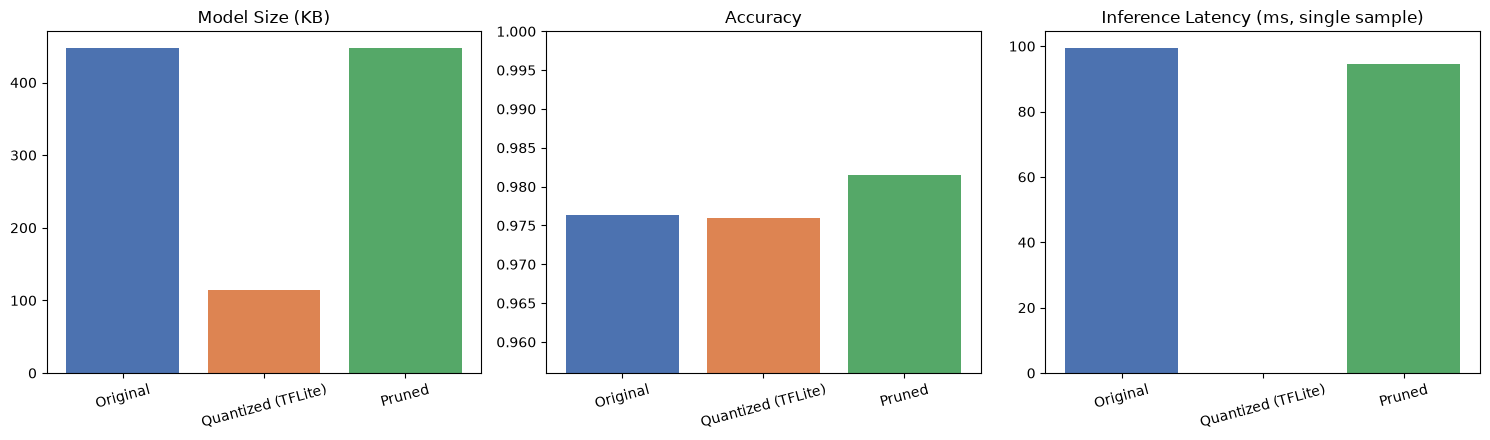

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#4C72B0", "#DD8452", "#55A868"]

axes[0].bar(results["version"], results["size_kb"], color=colors)
axes[0].set_title("Model Size (KB)")
axes[0].tick_params(axis="x", labelrotation=15)

axes[1].bar(results["version"], results["accuracy"], color=colors)
axes[1].set_title("Accuracy")
axes[1].set_ylim(min(results["accuracy"]) - 0.02, 1.0)
axes[1].tick_params(axis="x", labelrotation=15)

axes[2].bar(results["version"], results["latency_ms"], color=colors)
axes[2].set_title("Inference Latency (ms, single sample)")
axes[2].tick_params(axis="x", labelrotation=15)

plt.tight_layout()
plt.savefig(FIGURES / "01_optimization_comparison.png", dpi=150)
plt.show()

## Conclusion

Post-training quantization and magnitude-based pruning were applied to the Experiment 2 MNIST
baseline ANN. Results from this run are captured in `results.csv` and the comparison plot above,
showing the measured trade-off between model size, accuracy, and single-sample inference latency
for the original, quantized (TensorFlow Lite), and pruned versions of the model.